# Evaluate CNN-BiLSTM with Attention Multi-View Model
This notebook evaluates the trained multi-view CNN-BiLSTM model on the test dataset.

In [6]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [7]:
PROC_DIR = "."
test_df = pd.read_csv("../Datasets/test_interpolated_multiview.csv")

import json
from sklearn.preprocessing import LabelEncoder
with open("../api/labels.json", "r", encoding="utf-8") as f:
    labels_dict = json.load(f)
classes = [labels_dict[str(i)]["id"] for i in range(len(labels_dict))]
le = LabelEncoder()
le.fit(classes)
test_df['label'] = le.transform(test_df['label'])
print(f"Test samples: {len(test_df)}")

Test samples: 15294


In [8]:
class SignDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(f"{PROC_DIR}/{row.file}").astype(np.float32)
        y = int(row.label)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.df)

test_loader = DataLoader(SignDataset(test_df), batch_size=32, shuffle=False)

In [9]:
import torch.nn as nn

class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_dim=387, num_classes=401, conv_filters=128, lstm_hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=input_dim, out_channels=conv_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_filters),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=conv_filters, out_channels=conv_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_filters),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.lstm = nn.LSTM(
            input_size=conv_filters,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        self.attention = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)
        
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.transpose(1, 2)
        lstm_out, _ = self.lstm(x)
        attn_weights = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(lstm_out * attn_weights, dim=1)
        out = self.fc(context)
        return out

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
input_dim = 387
num_classes = len(classes)

model = CNNBiLSTMAttention(input_dim, num_classes).to(device)
model.load_state_dict(torch.load("../Models/cnn_bilstm_attention_interpolated_multiview.pth", map_location=device))
model.eval()
print("Using device:", device)
print("Model loaded successfully!")

Using device: cuda
Model loaded successfully!


In [11]:
all_preds = []
all_targets = []

with torch.no_grad():
    for X, y in tqdm(test_loader, desc="Evaluating"):
        X = X.to(device)
        preds = model(X)
        all_preds.extend(preds.argmax(dim=1).cpu().numpy())
        all_targets.extend(y.numpy())

ref_words = le.inverse_transform(all_targets)
pred_words = le.inverse_transform(all_preds)

incorrect = sum(1 for r, p in zip(ref_words, pred_words) if r != p)
wer = incorrect / len(ref_words)
accuracy = 1.0 - wer

print(f"========================================")
print(f"   WORD-LEVEL EVALUATION METRICS (CNN-BiLSTM)")
print(f"========================================")
print(f"Total Test Samples: {len(ref_words)}")
print(f"Correct Words: {len(ref_words) - incorrect}")
print(f"Incorrect Words (Substitutions): {incorrect}")
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Word Error Rate (WER): {wer:.4f} ({wer * 100:.2f}%)")

print("\nClassification Report:")
print(classification_report(all_targets, all_preds, labels=list(range(len(classes))), target_names=classes, zero_division=0))

Evaluating: 100%|██████████| 478/478 [02:00<00:00,  3.96it/s]

   WORD-LEVEL EVALUATION METRICS (CNN-BiLSTM)
Total Test Samples: 15294
Correct Words: 14106
Incorrect Words (Substitutions): 1188
Accuracy: 0.9223 (92.23%)
Word Error Rate (WER): 0.0777 (7.77%)

Classification Report:
              precision    recall  f1-score   support

        W001       0.84      0.84      0.84        37
        W002       0.97      0.87      0.92        39
        W003       0.95      0.95      0.95        42
        W004       0.91      0.89      0.90        36
        W005       0.87      0.87      0.87        38
        W006       0.75      0.89      0.81        37
        W007       0.93      0.95      0.94        39
        W008       0.88      1.00      0.94        38
        W009       0.87      0.85      0.86        40
        W010       0.91      0.88      0.90        34
        W011       0.92      1.00      0.96        36
        W012       0.90      0.90      0.90        42
        W013       0.82      0.84      0.83        37
        W014       0.97 

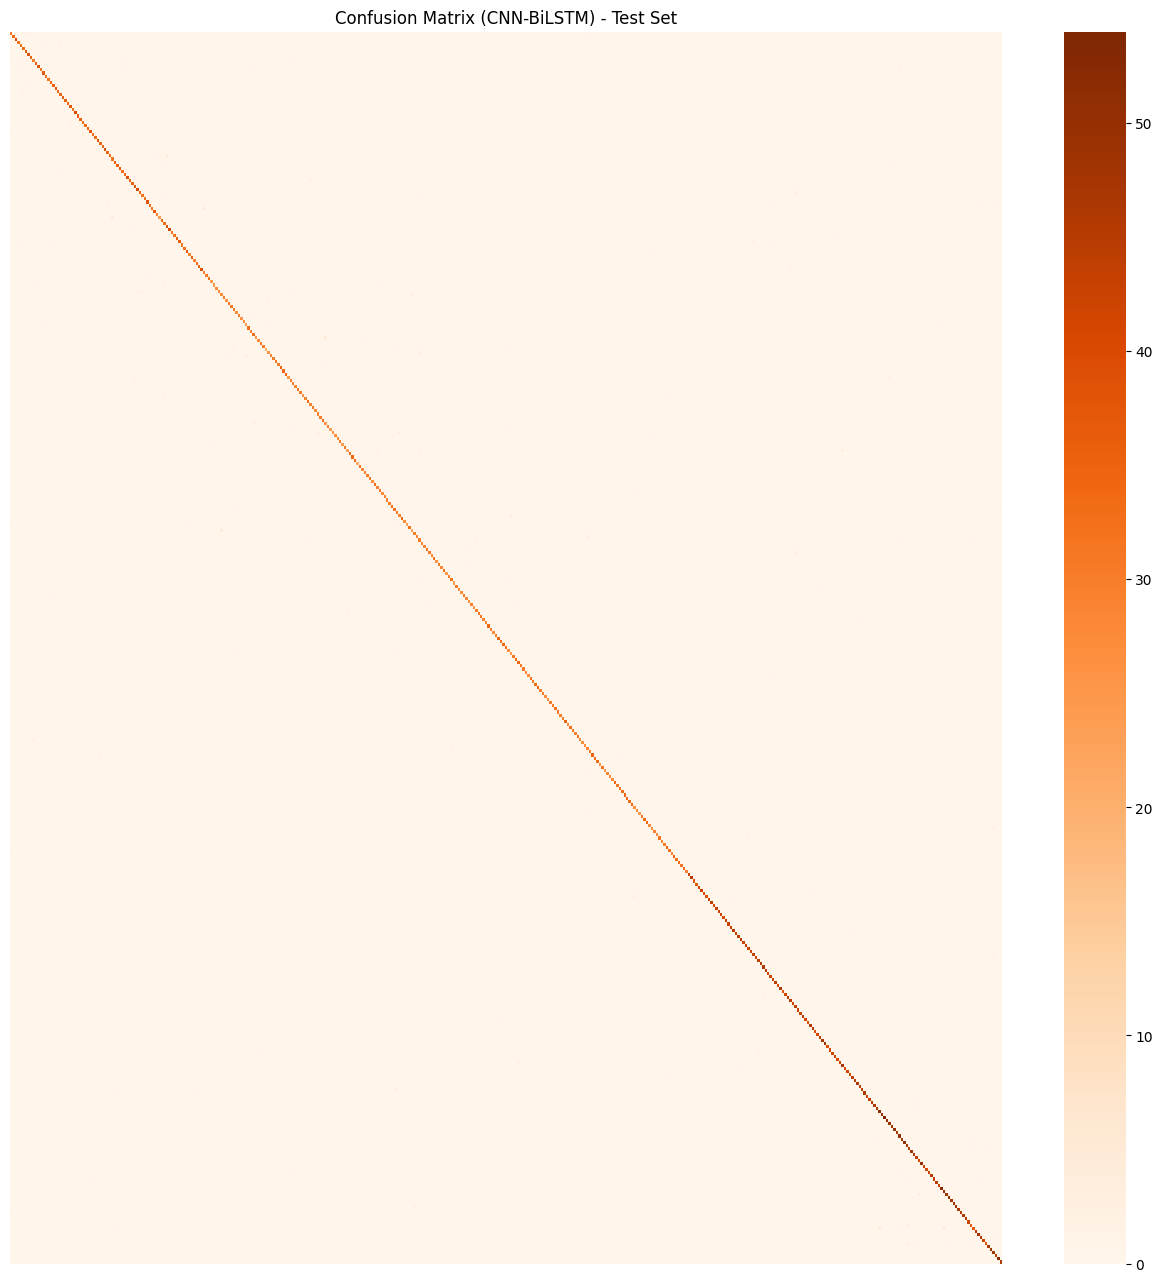

In [12]:
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(16, 16))
sns.heatmap(cm, cmap="Oranges", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix (CNN-BiLSTM) - Test Set")
plt.show()